Explained Variance Ratio: [0.22255912 0.21337348]
Total Variance Explained: 0.43593260694669445


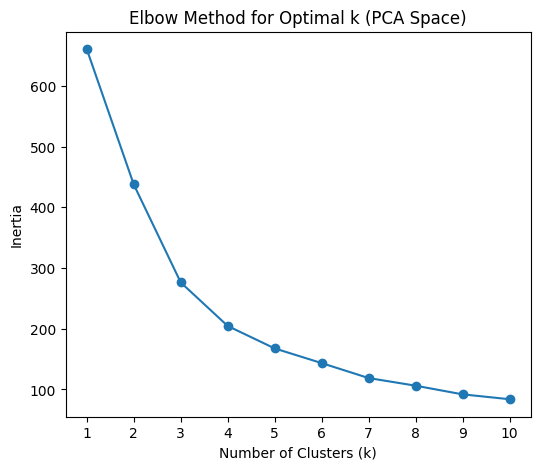

Silhouette Score (PCA): 0.35599823437234174


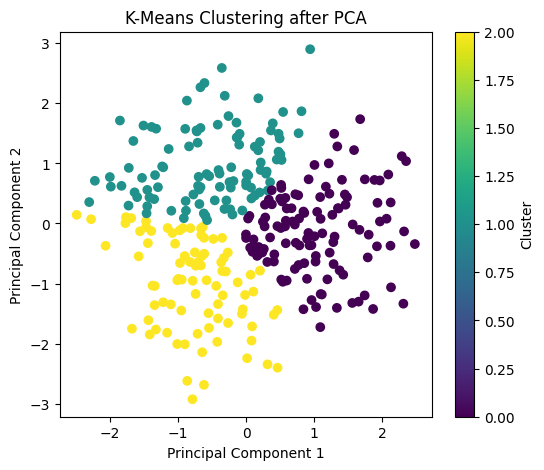

In [1]:
# ================================
# PCA + K-Means Clustering
# ================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt


# 1) Load dataset
df = pd.read_csv("/content/heart_disease_kaggle.csv")


# 2) Select continuous features
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
X = df[features]


# 3) Feature Scaling (required)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 4) Apply PCA (2 components for visualization & structure analysis)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# 5) Check explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", pca.explained_variance_ratio_.sum())


# ================================
# Elbow Method Visualization
# ================================

inertia = []

K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k (PCA Space)")
plt.xticks(K_range)
plt.show()


# 6) K-Means clustering on PCA space
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df["Cluster_PCA"] = clusters


# 7) Evaluate clustering quality
sil_score = silhouette_score(X_pca, clusters)
print("Silhouette Score (PCA):", sil_score)


# 8) Visualization of clusters using PCA components
plt.figure(figsize=(6,5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Cluster_PCA"],
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering after PCA")
plt.colorbar(label="Cluster")
plt.show()
